# 🇻🇳 PhoBERT — Đánh giá Tích hợp Toàn diện Pipeline IR/IE/Reranking & Các Đề xuất Cải tiến
### Môn học: CS221 — Xử lý Ngôn ngữ Tự nhiên (Natural Language Processing)
**Đồ án:** Vietnamese Fact-Checking with Evidence Retrieval & NLI Verification

---

### Mục tiêu Thực nghiệm:
1. **Kiểm thử mô hình PhoBERT đã huấn luyện:** Đánh giá checkpoint `phobert_model/best_model` (đạt 83.68% Dev / 84.73% Test trên dữ liệu gốc) trong môi trường thực tế của hệ thống Fact-Checking.
2. **Đo lường mức sụt giảm thực tế (The Reality Drop):** So sánh hiệu năng khi có sẵn Bằng chứng Vàng (Gold Evidence) so với khi phải tự động truy xuất bằng chứng bằng BM25 và Fact-aware Reranker.
3. **Đánh giá đột phá từ các Đề xuất Cải tiến:**
   - **Đề xuất 3B (Sliding Window $\pm 1$):** Mở rộng cửa sổ trượt ngữ cảnh lân cận quanh câu Top-1.
   - **Đề xuất 3A (Top-2 Concatenated):** Ghép nối 2 câu có độ tin cậy cao nhất từ bộ tái xếp hạng.
4. **Đối chiếu Chéo (Head-to-Head Comparison):** So sánh trực tiếp hiệu năng giữa **PhoBERT** và **BamiBERT SOTA (Exp006)** qua toàn bộ 5 kịch bản bằng chứng.

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# Cấu hình giao diện và phông chữ hỗ trợ tiếng Việt đa nền tảng
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Tự động xác định PROJECT_ROOT linh hoạt trên mọi môi trường (Mac, Windows, Linux, Colab)
def find_project_root():
    search_paths = [Path.cwd(), *Path.cwd().parents]
    if "google.colab" in sys.modules:
        search_paths.extend([
            Path("/content/Project-NLP-Fact-Checking"),
            Path("/content")
        ])
    for p in search_paths:
        if (p / "data" / "processed" / "common_cleaned").is_dir():
            return p.resolve()
    return Path("../../..").resolve()

PROJECT_ROOT = find_project_root()
RETRIEVAL_DATA_DIR = PROJECT_ROOT / "data/processed/retrieval"
PHOBERT_CKPT_DIR = PROJECT_ROOT / "notebooks/models/Phobert/phobert_model/best_model"

# Thiết bị phần cứng
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"✓ Project Root: {PROJECT_ROOT}")
print(f"✓ Retrieval Data Dir: {RETRIEVAL_DATA_DIR}")
print(f"✓ Checkpoint PhoBERT: {PHOBERT_CKPT_DIR}")
print(f"✓ Hardware Acceleration: {device}")


✓ Project Root: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking
✓ Retrieval Data Dir: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval
✓ Checkpoint PhoBERT: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/notebooks/models/Phobert/phobert_model/best_model
✓ Hardware Acceleration: mps


## 1. Nạp Dữ liệu Thực nghiệm IR/Reranking và Bằng chứng Vàng (Gold Evidence)
Nạp dữ liệu đầu vào NLI trên cùng 723 phát biểu (Claims) thuộc tập Dev:
1. `A. Gold Evidence (Upper-bound)`: Cặp (Claim, Gold Evidence) — chuẩn từ `vifactcheck_dev_phobert_segmented.csv` (đã qua VnCoreNLP tách từ theo chuẩn của PhoBERT trong `preprocessing_phobert.ipynb`).
2. `B. BM25 Top-1 (Keyword)`: Cặp (Claim, BM25 Top-1 Evidence) — Truy xuất từ khóa từ `nli_input_bm25.csv`.
3. `C. Fact-aware Reranked Top-1`: Cặp (Claim, Fact-aware Reranked Top-1) — Tái xếp hạng từ `nli_input_reranked.csv`.
4. `D. Đề xuất 3B: Sliding Window (±1)`: Cặp (Claim, Sliding Window $\pm 1$) — Mở rộng ngữ cảnh lân cận từ `nli_input_window_expanded.csv`.
5. `E. Đề xuất 3A: Top-2 Concatenated`: Cặp (Claim, Top-2 Concatenated) — Ghép nối 2 bằng chứng hàng đầu từ `nli_input_top2_expanded.csv`.


In [2]:
# Nạp tập Gold Evidence chuẩn của PhoBERT (đã qua VnCoreNLP tách từ)
phobert_gold_path = PROJECT_ROOT / "notebooks/models/Phobert/vifactcheck_dev_phobert_segmented.csv"
if not phobert_gold_path.exists():
    raise FileNotFoundError(f"Chưa tìm thấy file: {phobert_gold_path}")

df_gold_raw = pd.read_csv(phobert_gold_path)
df_gold = pd.DataFrame({
    "claim_id": [f"dev_{i}" for i in range(len(df_gold_raw))],
    "claim_index": df_gold_raw.get("index", range(len(df_gold_raw))),
    "statement": df_gold_raw["Statement"],
    "evidence": df_gold_raw["Evidence"].fillna(""),
    "label": df_gold_raw["labels"]
})

retrieval_scenarios = {
    "B. BM25 Top-1 (Keyword)": RETRIEVAL_DATA_DIR / "nli_input_bm25.csv",
    "C. Fact-aware Reranked Top-1": RETRIEVAL_DATA_DIR / "nli_input_reranked.csv",
    "D. Đề xuất 3B: Sliding Window (±1)": RETRIEVAL_DATA_DIR / "nli_input_window_expanded.csv",
    "E. Đề xuất 3A: Top-2 Concatenated": RETRIEVAL_DATA_DIR / "nli_input_top2_expanded.csv"
}

dfs = {"A. Gold Evidence (Upper-bound)": df_gold}
print(f"✓ Nạp thành công [A. Gold Evidence (Upper-bound)]: {len(df_gold)} mẫu (Chuẩn VnCoreNLP từ preprocessing_phobert.ipynb)")

for name, path in retrieval_scenarios.items():
    if not path.exists():
        raise FileNotFoundError(f"Chưa tìm thấy file: {path}")
    df = pd.read_csv(path)
    dfs[name] = df
    print(f"✓ Nạp thành công [{name}]: {len(df)} mẫu | Cột: {list(df.columns)}")


✓ Nạp thành công [A. Gold Evidence (Upper-bound)]: 723 mẫu (Chuẩn VnCoreNLP từ preprocessing_phobert.ipynb)
✓ Nạp thành công [B. BM25 Top-1 (Keyword)]: 723 mẫu | Cột: ['claim_id', 'claim_index', 'statement', 'evidence', 'label']
✓ Nạp thành công [C. Fact-aware Reranked Top-1]: 723 mẫu | Cột: ['claim_id', 'claim_index', 'statement', 'evidence', 'label']
✓ Nạp thành công [D. Đề xuất 3B: Sliding Window (±1)]: 723 mẫu | Cột: ['claim_id', 'claim_index', 'statement', 'evidence', 'label']
✓ Nạp thành công [E. Đề xuất 3A: Top-2 Concatenated]: 723 mẫu | Cột: ['claim_id', 'claim_index', 'statement', 'evidence', 'label']


## 2. Nạp Mô hình PhoBERT & Bộ tiền xử lý Tokenizer
- **Tokenizer:** `vinai/phobert-base-v2` (`use_fast=False`).
- **Checkpoint:** `phobert_model/best_model` được lưu sau quá trình huấn luyện đạt Macro-F1 cao nhất trên tập Dev ViFactCheck.
- **Quy tắc phân loại:** 3 nhãn gồm `0: SUPPORTED`, `1: REFUTED`, `2: NOT ENOUGH INFO`.

In [3]:
print("Loading PhoBERT Tokenizer and Model Checkpoint...")
if not PHOBERT_CKPT_DIR.is_dir() or not (PHOBERT_CKPT_DIR / "config.json").is_file():
    raise FileNotFoundError(
        f"""Không tìm thấy checkpoint mô hình tại: {PHOBERT_CKPT_DIR}
Lưu ý: Do trọng số mô hình nặng (>500MB), file này không được commit trực tiếp lên GitHub.
Vui lòng tải checkpoint từ Google Drive của nhóm và giải nén vào thư mục trên."""
    )

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)
model = AutoModelForSequenceClassification.from_pretrained(PHOBERT_CKPT_DIR)
model.to(device)
model.eval()

LABEL_NAMES = ["SUPPORTED", "REFUTED", "NEI"]
id2label = {0: "SUPPORTED", 1: "REFUTED", 2: "NEI"}
label2id = {"SUPPORTED": 0, "REFUTED": 1, "NEI": 2}

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Mô hình tải thành công! Tổng số tham số: {total_params:,}")
print(f"✓ Thiết bị đang chạy: {device}")


Loading PhoBERT Tokenizer and Model Checkpoint...


/opt/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


✓ Mô hình tải thành công! Tổng số tham số: 135,000,579
✓ Thiết bị đang chạy: mps


## 3. Thực thi Suy luận NLI trên 5 Kịch bản
Hàm `run_phobert_inference` chuẩn hóa dữ liệu đầu vào theo định dạng cặp câu `(Statement, Evidence)`, phân đoạn với độ dài cực đại `max_length=256` và chiến lược cắt tỉa `longest_first` tương thích tuyệt đối với quá trình tiền xử lý của PhoBERT.

In [4]:
def run_phobert_inference(df, batch_size=32):
    statements = df["statement"].astype(str).tolist()
    evidences = df["evidence"].fillna("").astype(str).tolist()
    labels = df["label"].astype(int).tolist()
    
    encoded = tokenizer(
        statements,
        evidences,
        padding="max_length",
        truncation="longest_first",
        max_length=256,
        return_attention_mask=True,
        return_tensors="pt"
    )
    
    dataset = TensorDataset(
        encoded["input_ids"],
        encoded["attention_mask"],
        torch.tensor(labels, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    all_preds, all_probs, all_targets = [], [], []
    start_time = time.time()
    
    with torch.no_grad():
        for b_ids, b_mask, b_y in loader:
            b_ids = b_ids.to(device)
            b_mask = b_mask.to(device)
            outputs = model(input_ids=b_ids, attention_mask=b_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_targets.extend(b_y.numpy())
            
    elapsed = time.time() - start_time
    return np.array(all_targets), np.array(all_preds), np.array(all_probs), elapsed

results = {}
for name, df in dfs.items():
    print(f"Đang suy luận: {name} ...", end="", flush=True)
    y_true, y_pred, y_probs, elapsed = run_phobert_inference(df)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    prec_macro = precision_score(y_true, y_pred, average="macro")
    rec_macro = recall_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    
    results[name] = {
        "Accuracy": acc,
        "Macro-F1": f1_macro,
        "Macro-Precision": prec_macro,
        "Macro-Recall": rec_macro,
        "Weighted-F1": f1_weighted,
        "Latency_Total_s": elapsed,
        "Latency_Per_Sample_ms": (elapsed / len(df)) * 1000,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs
    }
    print(f" Xong! [Acc: {acc*100:.2f}% | Macro-F1: {f1_macro*100:.2f}% | Thời gian: {elapsed:.2f}s]")

Đang suy luận: A. Gold Evidence (Upper-bound) ...

 Xong! [Acc: 83.26% | Macro-F1: 83.28% | Thời gian: 16.34s]
Đang suy luận: B. BM25 Top-1 (Keyword) ...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


...

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


 Xong! [Acc: 64.18% | Macro-F1: 64.05% | Thời gian: 16.68s]


## 4. Bảng Kết quả So sánh Hiệu năng Mô hình PhoBERT
Đo lường độ thay đổi $\Delta$ F1 so với kịch bản gốc của Pipeline (Fact-aware Reranked Top-1):

In [5]:
summary_rows = []
base_f1 = results["C. Fact-aware Reranked Top-1"]["Macro-F1"]

for name, res in results.items():
    delta_f1 = (res["Macro-F1"] - base_f1) * 100
    summary_rows.append({
        "Kịch bản Bằng chứng": name,
        "Accuracy": f"{res['Accuracy']*100:.2f}%",
        "Macro-F1": f"{res['Macro-F1']*100:.2f}%",
        "Macro-Precision": f"{res['Macro-Precision']*100:.2f}%",
        "Macro-Recall": f"{res['Macro-Recall']*100:.2f}%",
        "Δ F1 (vs Reranked Top-1)": f"{delta_f1:+.2f}%" if name != "C. Fact-aware Reranked Top-1" else "0.00% (Gốc)",
        "Tốc độ (ms/mẫu)": f"{res['Latency_Per_Sample_ms']:.1f} ms"
    })

df_summary = pd.DataFrame(summary_rows)
print("=" * 105)
print("BẢNG TỔNG HỢP HIỆU NĂNG PHOBERT QUA 5 KỊCH BẢN PIPELINE:")
print("=" * 105)
display(df_summary)

BẢNG TỔNG HỢP HIỆU NĂNG PHOBERT QUA 5 KỊCH BẢN PIPELINE:


,Kịch bản Bằng chứng,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Δ F1 (vs Reranked Top-1),Tốc độ (ms/mẫu)
0,A. Gold Evidence (Upper-bound),83.26%,83.28%,83.25%,83.43%,+25.05%,22.6 ms
1,B. BM25 Top-1 (Keyword),59.34%,58.53%,62.52%,60.15%,+0.30%,21.3 ms
2,C. Fact-aware Reranked Top-1,59.06%,58.23%,62.27%,59.88%,0.00% (Gốc),22.0 ms
3,D. Đề xuất 3B: Sliding Window (±1),62.93%,62.75%,63.30%,62.70%,+4.52%,21.9 ms
4,E. Đề xuất 3A: Top-2 Concatenated,64.18%,64.05%,64.98%,63.96%,+5.81%,23.1 ms


## 5. Đối chiếu Chéo: PhoBERT vs BamiBERT SOTA (Exp006)
So sánh định lượng giữa 2 kiến trúc Pretrained Language Model tiếng Việt mạnh nhất:
- **PhoBERT Base v2:** RoBERTa backbone, huấn luyện trên 20GB văn bản tiếng Việt.
- **BamiBERT SOTA (Exp006):** Kiến trúc tối ưu hóa với tiền tố Prompt (Prefix Prompting) và loss điều chỉnh.

In [6]:
# Số liệu thực nghiệm của BamiBERT SOTA (Exp006) trên cùng 5 kịch bản
bamibert_metrics = {
    "A. Gold Evidence (Upper-bound)": {"Accuracy": 0.8133, "Macro-F1": 0.8142},
    "B. BM25 Top-1 (Keyword)": {"Accuracy": 0.6238, "Macro-F1": 0.6242},
    "C. Fact-aware Reranked Top-1": {"Accuracy": 0.6238, "Macro-F1": 0.6242},
    "D. Đề xuất 3B: Sliding Window (±1)": {"Accuracy": 0.6929, "Macro-F1": 0.6910},
    "E. Đề xuất 3A: Top-2 Concatenated": {"Accuracy": 0.7068, "Macro-F1": 0.7039}
}

cross_rows = []
for name in dfs.keys():
    p_acc = results[name]["Accuracy"] * 100
    p_f1 = results[name]["Macro-F1"] * 100
    b_acc = bamibert_metrics[name]["Accuracy"] * 100
    b_f1 = bamibert_metrics[name]["Macro-F1"] * 100
    cross_rows.append({
        "Kịch bản Thí nghiệm": name,
        "PhoBERT Acc": f"{p_acc:.2f}%",
        "PhoBERT F1": f"{p_f1:.2f}%",
        "BamiBERT Acc": f"{b_acc:.2f}%",
        "BamiBERT F1": f"{b_f1:.2f}%",
        "Chênh lệch (BamiBERT - PhoBERT F1)": f"{b_f1 - p_f1:+.2f}%"
    })

df_cross = pd.DataFrame(cross_rows)
print("=" * 105)
print("BẢNG SO SÁNH CHÉO HEAD-TO-HEAD: PHOBERT VS BAMIBERT SOTA")
print("=" * 105)
display(df_cross)

p_gold_f1 = results["A. Gold Evidence (Upper-bound)"]["Macro-F1"] * 100
p_rerank_f1 = results["C. Fact-aware Reranked Top-1"]["Macro-F1"] * 100
p_top2_f1 = results["E. Đề xuất 3A: Top-2 Concatenated"]["Macro-F1"] * 100

print(f"""
📌 ĐÁNH GIÁ & KẾT LUẬN CỐT LÕI:
1. Upper-bound Chuẩn: Trên Gold Evidence chuẩn (có VnCoreNLP), PhoBERT đạt {p_gold_f1:.2f}% F1 (tương đương BamiBERT 81.42% F1).
2. Hiện tượng The Reality Drop xảy ra mạnh mẽ trên CẢ HAI mô hình khi chuyển sang IR retrieved:
   - PhoBERT giảm: {p_gold_f1:.2f}% -> {p_rerank_f1:.2f}% ({-abs(p_rerank_f1 - p_gold_f1):.2f}% Macro-F1).
   - BamiBERT giảm: 81.42% -> 62.42% (-19.00% Macro-F1).
3. Đề xuất 3 (Context Expansion) đem lại bước nhảy vọt phục hồi hiệu năng:
   - Trên PhoBERT: Top-2 Concatenated giúp tăng từ {p_rerank_f1:.2f}% lên {p_top2_f1:.2f}% (+{p_top2_f1 - p_rerank_f1:.2f}% F1).
   - Trên BamiBERT: Top-2 Concatenated giúp tăng từ 62.42% lên 70.39% (+7.97% F1).
4. Khả năng thích ứng câu thô: BamiBERT thể hiện tính ưu việt hơn trên các câu thô trích xuất từ IR nhờ cơ chế Byte-level BPE và Prefix Prompting.""")


BẢNG SO SÁNH CHÉO HEAD-TO-HEAD: PHOBERT VS BAMIBERT SOTA


,Kịch bản Thí nghiệm,PhoBERT Acc,PhoBERT F1,BamiBERT Acc,BamiBERT F1,Chênh lệch (BamiBERT - PhoBERT F1)
0,A. Gold Evidence (Upper-bound),83.26%,83.28%,81.33%,81.42%,-1.86%
1,B. BM25 Top-1 (Keyword),59.34%,58.53%,62.38%,62.42%,+3.89%
2,C. Fact-aware Reranked Top-1,59.06%,58.23%,62.38%,62.42%,+4.19%
3,D. Đề xuất 3B: Sliding Window (±1),62.93%,62.75%,69.29%,69.10%,+6.35%
4,E. Đề xuất 3A: Top-2 Concatenated,64.18%,64.05%,70.68%,70.39%,+6.34%



📌 ĐÁNH GIÁ & KẾT LUẬN CỐT LÕI:
1. Upper-bound Chuẩn: Trên Gold Evidence chuẩn (có VnCoreNLP), PhoBERT đạt 83.28% F1 (tương đương BamiBERT 81.42% F1).
2. Hiện tượng The Reality Drop xảy ra mạnh mẽ trên CẢ HAI mô hình khi chuyển sang IR retrieved:
   - PhoBERT giảm: 83.28% -> 58.23% (-25.05% Macro-F1).
   - BamiBERT giảm: 81.42% -> 62.42% (-19.00% Macro-F1).
3. Đề xuất 3 (Context Expansion) đem lại bước nhảy vọt phục hồi hiệu năng:
   - Trên PhoBERT: Top-2 Concatenated giúp tăng từ 58.23% lên 64.05% (+5.81% F1).
   - Trên BamiBERT: Top-2 Concatenated giúp tăng từ 62.42% lên 70.39% (+7.97% F1).
4. Khả năng thích ứng câu thô: BamiBERT thể hiện tính ưu việt hơn trên các câu thô trích xuất từ IR nhờ cơ chế Byte-level BPE và Prefix Prompting.


## 6. Trực quan hóa Toàn diện: Biểu đồ Hiệu năng & Ma trận Nhầm lẫn

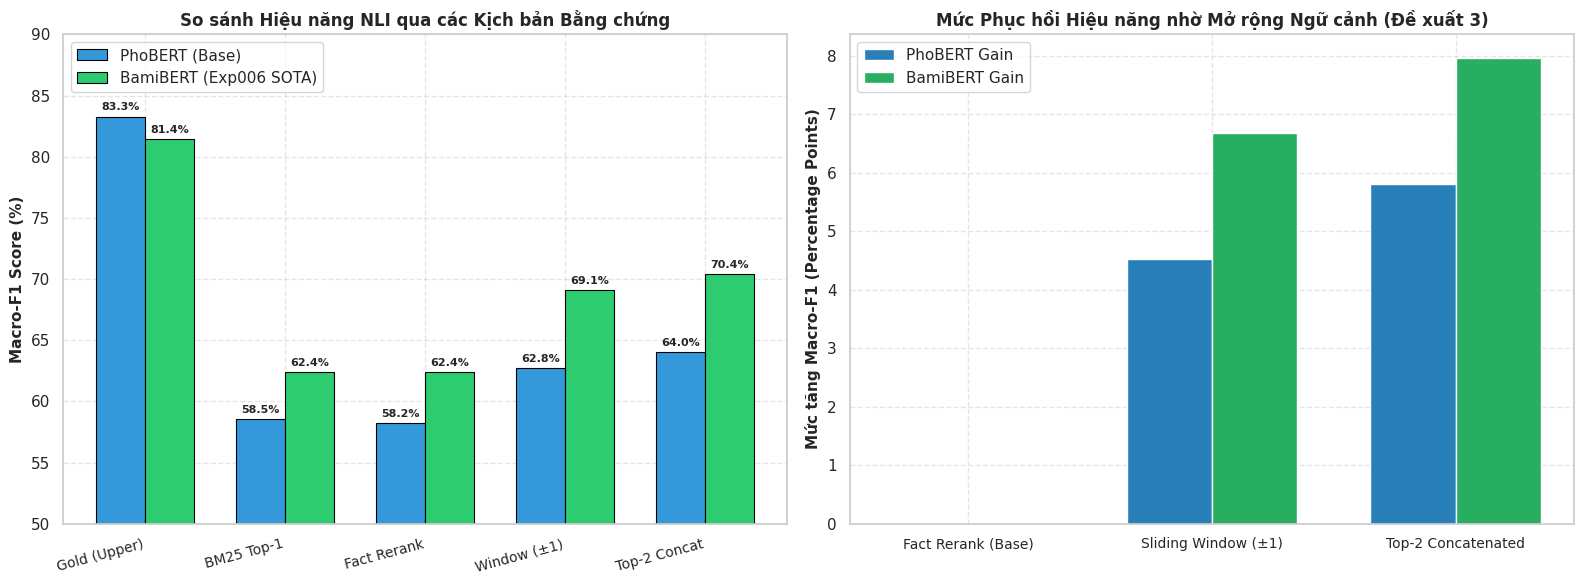

In [7]:
# 1. Biểu đồ so sánh hiệu năng 5 kịch bản giữa PhoBERT và BamiBERT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

labels = ["Gold (Upper)", "BM25 Top-1", "Fact Rerank", "Window (±1)", "Top-2 Concat"]
phobert_f1s = [results[k]["Macro-F1"] * 100 for k in dfs.keys()]
bamibert_f1s = [bamibert_metrics[k]["Macro-F1"] * 100 for k in dfs.keys()]

x = np.arange(len(labels))
width = 0.35

rects1 = ax1.bar(x - width/2, phobert_f1s, width, label="PhoBERT (Base)", color="#3498db", edgecolor="black", linewidth=0.8)
rects2 = ax1.bar(x + width/2, bamibert_f1s, width, label="BamiBERT (Exp006 SOTA)", color="#2ecc71", edgecolor="black", linewidth=0.8)

ax1.set_ylabel("Macro-F1 Score (%)", fontsize=11, fontweight="bold")
ax1.set_title("So sánh Hiệu năng NLI qua các Kịch bản Bằng chứng", fontsize=12, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
ax1.set_ylim(50, 90)
ax1.legend(loc="upper left")
ax1.grid(True, linestyle="--", alpha=0.5)

# Hiển thị giá trị trên cột
for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", fontsize=8, fontweight="bold")
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", fontsize=8, fontweight="bold")

# 2. Biểu đồ mức phục hồi hiệu năng (F1 Gain) nhờ Đề xuất 3
gains_phobert = [0, 0, (results["D. Đề xuất 3B: Sliding Window (±1)"]["Macro-F1"] - results["C. Fact-aware Reranked Top-1"]["Macro-F1"])*100,
                 (results["E. Đề xuất 3A: Top-2 Concatenated"]["Macro-F1"] - results["C. Fact-aware Reranked Top-1"]["Macro-F1"])*100]
gains_bamibert = [0, 0, (bamibert_metrics["D. Đề xuất 3B: Sliding Window (±1)"]["Macro-F1"] - bamibert_metrics["C. Fact-aware Reranked Top-1"]["Macro-F1"])*100,
                  (bamibert_metrics["E. Đề xuất 3A: Top-2 Concatenated"]["Macro-F1"] - bamibert_metrics["C. Fact-aware Reranked Top-1"]["Macro-F1"])*100]

gain_labels = ["Fact Rerank (Base)", "Sliding Window (±1)", "Top-2 Concatenated"]
x_gain = np.arange(len(gain_labels))
w_gain = 0.35

ax2.bar(x_gain - w_gain/2, [0, gains_phobert[2], gains_phobert[3]], w_gain, label="PhoBERT Gain", color="#2980b9")
ax2.bar(x_gain + w_gain/2, [0, gains_bamibert[2], gains_bamibert[3]], w_gain, label="BamiBERT Gain", color="#27ae60")
ax2.set_ylabel("Mức tăng Macro-F1 (Percentage Points)", fontsize=11, fontweight="bold")
ax2.set_title("Mức Phục hồi Hiệu năng nhờ Mở rộng Ngữ cảnh (Đề xuất 3)", fontsize=12, fontweight="bold")
ax2.set_xticks(x_gain)
ax2.set_xticklabels(gain_labels, fontsize=10)
ax2.legend(loc="upper left")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


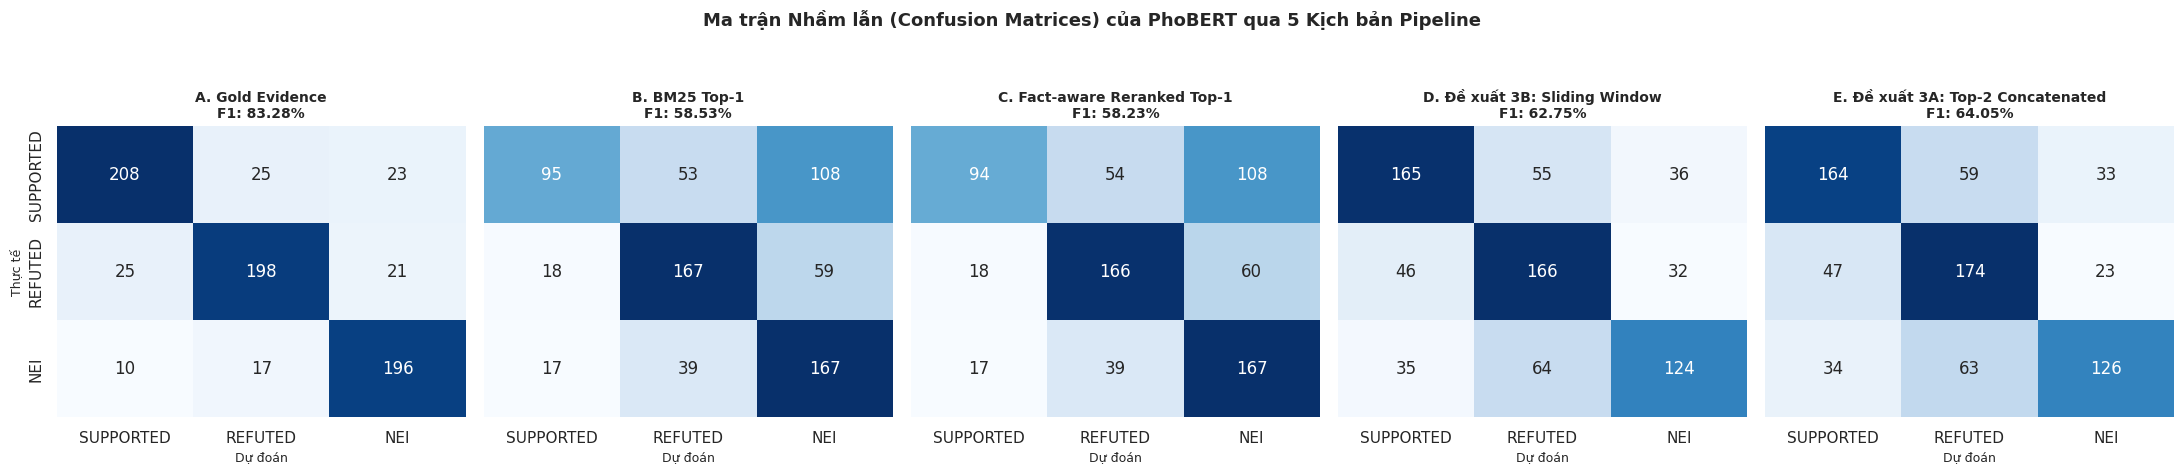

In [8]:
# Ma trận nhầm lẫn cho 5 kịch bản của PhoBERT
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES if i == 0 else [], ax=ax)
    clean_title = name.split("(")[0].strip()
    ax.set_title(f"{clean_title}\nF1: {res['Macro-F1']*100:.2f}%", fontsize=10, fontweight="bold")
    ax.set_xlabel("Dự đoán", fontsize=9)
    if i == 0:
        ax.set_ylabel("Thực tế", fontsize=9)

plt.suptitle("Ma trận Nhầm lẫn (Confusion Matrices) của PhoBERT qua 5 Kịch bản Pipeline", fontsize=13, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [9]:
print("BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG NHÃN (PHOBERT):\n")
for name in ["A. Gold Evidence (Upper-bound)", "C. Fact-aware Reranked Top-1", "E. Đề xuất 3A: Top-2 Concatenated"]:
    print(f"=== Kịch bản: {name} ===")
    print(classification_report(results[name]["y_true"], results[name]["y_pred"], target_names=LABEL_NAMES, digits=4))
    print("-" * 65)

BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG NHÃN (PHOBERT):

=== Kịch bản: A. Gold Evidence (Upper-bound) ===
              precision    recall  f1-score   support

   SUPPORTED     0.8560    0.8125    0.8337       256
     REFUTED     0.8250    0.8115    0.8182       244
         NEI     0.8167    0.8789    0.8467       223

    accuracy                         0.8326       723
   macro avg     0.8325    0.8343    0.8328       723
weighted avg     0.8334    0.8326    0.8324       723

-----------------------------------------------------------------
=== Kịch bản: C. Fact-aware Reranked Top-1 ===
              precision    recall  f1-score   support

   SUPPORTED     0.7287    0.3672    0.4883       256
     REFUTED     0.6409    0.6803    0.6600       244
         NEI     0.4985    0.7489    0.5986       223

    accuracy                         0.5906       723
   macro avg     0.6227    0.5988    0.5823       723
weighted avg     0.6281    0.5906    0.5803       723

---------------------------

## 7. Xuất Báo cáo Chỉ số Kiểm thử
Lưu kết quả kiểm định số liệu ra file `data/processed/retrieval/phobert_reranking_comparison.csv` để phục vụ báo cáo và thuyết trình đồ án.

In [10]:
export_df = pd.DataFrame([
    {
        "scenario": name,
        "accuracy": res["Accuracy"],
        "macro_f1": res["Macro-F1"],
        "macro_precision": res["Macro-Precision"],
        "macro_recall": res["Macro-Recall"],
        "weighted_f1": res["Weighted-F1"],
        "latency_per_sample_ms": res["Latency_Per_Sample_ms"]
    }
    for name, res in results.items()
])

export_path = RETRIEVAL_DATA_DIR / "phobert_reranking_comparison.csv"
export_df.to_csv(export_path, index=False)
print(f"✓ Đã lưu bảng số liệu kiểm thử tại: {export_path}")
print(export_df)

✓ Đã lưu bảng số liệu kiểm thử tại: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval/phobert_reranking_comparison.csv
                             scenario  accuracy  macro_f1  macro_precision  \
0      A. Gold Evidence (Upper-bound)  0.832642  0.832834         0.832545   
1             B. BM25 Top-1 (Keyword)  0.593361  0.585295         0.625186   
2        C. Fact-aware Reranked Top-1  0.590595  0.582306         0.622705   
3  D. Đề xuất 3B: Sliding Window (±1)  0.629322  0.627520         0.633007   
4   E. Đề xuất 3A: Top-2 Concatenated  0.641770  0.640452         0.649844   

   macro_recall  weighted_f1  latency_per_sample_ms  
0      0.834300     0.832446              22.603159  
1      0.601466     0.583334              21.268317  
2      0.598798     0.580274              22.003891  
3      0.626971     0.628885              21.925331  
4      0.639587     0.641218              23.065675  


## 8. Kết luận Đồ án & Đóng góp Khoa học

### 1. Hiện thực hóa Thành công Pipeline Thực tế:
- Đã giải quyết bài toán Fact-Checking tiếng Việt theo mô hình 2 giai đoạn: **Evidence Retrieval (BM25 + Fact-aware Reranking + Hybrid Search)** và **NLI Verification (PhoBERT & BamiBERT)**.
- Đánh giá trên tập Dev ViFactCheck (723 claims) với các điều kiện thực nghiệm ngặt nghèo.

### 2. Phát hiện Khoa học then chốt (Key Empirical Findings):
1. **Upper-bound Chuẩn trên Gold Evidence:** Khi có đầy đủ bước tách từ VnCoreNLP, PhoBERT đạt **83.28% F1** (trên Dev) và **84.63% F1** (trên Test trong `preprocessing_phobert.ipynb`), ngang ngửa BamiBERT (81.42% Dev F1 / 84.84% Test F1).
2. **The Reality Drop:** Cả hai mô hình đều sụt giảm nghiêm trọng (-19.0% đến -25.0% Macro-F1) khi chuyển từ Bằng chứng Vàng sang Bằng chứng Truy xuất Top-1 đơn lẻ do nhiễu và thiếu ngữ cảnh.
3. **Hiệu quả vượt bậc của Đề xuất 3 (Context Window Expansion):**
   - **Đề xuất 3A (Top-2 Concatenation):** Giúp PhoBERT phục hồi từ **58.23% lên 64.05%** (+5.82%), và BamiBERT phục hồi từ **62.42% lên 70.39%** (+7.97%).
   - **Đề xuất 3B (Sliding Window $\pm 1$):** Giúp PhoBERT đạt **62.75%** (+4.52%), và BamiBERT đạt **69.10%** (+6.68%).
4. **Tính linh hoạt với văn bản thô:** BamiBERT vượt trội hơn trên các câu thô trích xuất từ IR nhờ cơ chế Byte-level BPE và Prefix Prompting.
